In [28]:
import pandas as pd

fish = pd.read_csv('https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fish.csv')

fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [29]:
fish.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    str    
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), str(1)
memory usage: 7.6 KB


In [30]:
X = fish[fish.drop(columns=['Species']).columns].to_numpy()
y = fish['Species'].to_numpy()

In [31]:
fish.groupby(['Species'])['Species'].count()

Species
Bream        35
Parkki       11
Perch        56
Pike         17
Roach        20
Smelt        14
Whitefish     6
Name: Species, dtype: int64

In [32]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

kn = KNeighborsClassifier(n_neighbors=3)

kn.fit(X, y)

print(kn.classes_)

proba = kn.predict_proba(X[:5])
print(np.round(proba, decimals=4))

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
[[0.3333 0.     0.6667 0.     0.     0.     0.    ]
 [0.3333 0.3333 0.     0.     0.3333 0.     0.    ]
 [0.6667 0.     0.     0.3333 0.     0.     0.    ]
 [0.6667 0.     0.     0.3333 0.     0.     0.    ]
 [0.6667 0.     0.     0.3333 0.     0.     0.    ]]


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  X, y,
  test_size=0.2,
  random_state=42
)

In [34]:
X[:5]

array([[242.    ,  25.4   ,  30.    ,  11.52  ,   4.02  ],
       [290.    ,  26.3   ,  31.2   ,  12.48  ,   4.3056],
       [340.    ,  26.5   ,  31.1   ,  12.3778,   4.6961],
       [363.    ,  29.    ,  33.5   ,  12.73  ,   4.4555],
       [430.    ,  29.    ,  34.    ,  12.444 ,   5.134 ]])

In [35]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [36]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

bream_smelt_indexes = (y == "Bream") | (y == "Smelt")
train_scaled = ss.fit_transform(X_train)
test_scaled = ss.transform(X_test)

In [37]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, y_train)
print(kn.score(train_scaled, y_train))
print(kn.score(test_scaled, y_test))

0.8976377952755905
0.875


In [38]:
print(kn.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [39]:
print(kn.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']


In [40]:
import numpy as np

proba = kn.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=4))

[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [41]:
distance, indexes = kn.kneighbors(test_scaled[3:4])
print(y_train[indexes])

[['Roach' 'Perch' 'Perch']]


In [42]:
print(distance)

[[0.21006722 0.25099241 0.34168737]]


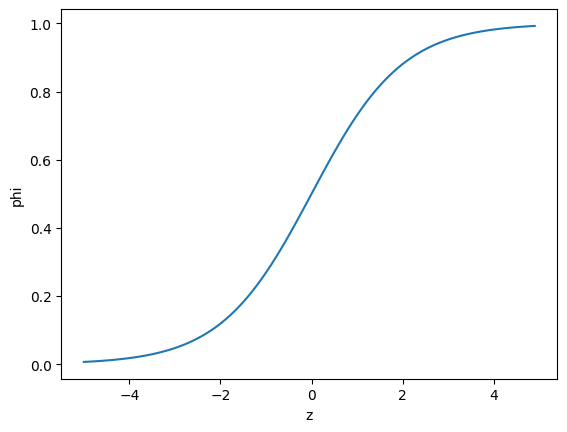

In [43]:
import numpy as np
import matplotlib.pyplot as plt
z = np.arange(-5, 5, 0.1)
phi = 1/(1+np.exp(-z))
plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()

In [44]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

bs_fish = fish[bream_smelt_indexes]

X_train_bream_smelt, X_test_bream_smelt, y_train_bream_smelt, y_test_bream_smelt = train_test_split(
  fish[fish.drop(columns=['Species']).columns][bream_smelt_indexes],
  fish['Species'][bream_smelt_indexes],
  test_size=0.2,
  random_state=42
)

In [45]:
lr.fit(X_train_bream_smelt, y_train_bream_smelt)
print(lr.predict(X_train_bream_smelt[:5]))
print(y_train_bream_smelt[:5])


['Bream' 'Bream' 'Bream' 'Bream' 'Bream']
12    Bream
4     Bream
34    Bream
8     Bream
3     Bream
Name: Species, dtype: str


In [46]:
print(lr.classes_)

['Bream' 'Smelt']


In [47]:
print(lr.predict_proba(X_train_bream_smelt[:5]))

[[1.00000000e+00 4.83035458e-13]
 [1.00000000e+00 1.21683181e-10]
 [1.00000000e+00 1.89549249e-28]
 [1.00000000e+00 2.48821825e-11]
 [9.99999976e-01 2.35850027e-08]]


In [48]:
print(lr.coef_, lr.intercept_)

decisions = lr.decision_function(X_train_bream_smelt[:5])
print(decisions)

[[-0.07857215 -0.00451672 -0.00588868 -0.00325943 -0.00088286]] [11.33271926]
[-28.35868633 -22.82960032 -63.83290391 -24.41686913 -17.56265478]


In [49]:
from scipy.special import expit
print(expit(decisions))

[4.83035458e-13 1.21683181e-10 1.89549249e-28 2.48821825e-11
 2.35850027e-08]


In [50]:
print(np.round(lr.predict_proba(X_train_bream_smelt[:5]), 3))

[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [51]:
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(X_train, y_train)
print(lr.score(X_train, y_train))
print(lr.score(X_test, y_test))


0.9921259842519685
0.90625


c:\2026-05-19_KDT_lang_chain\workspace\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [52]:
print(lr.predict(X_test[:5]))
print(y_test[:5])

['Perch' 'Smelt' 'Smelt' 'Roach' 'Perch']
['Perch' 'Smelt' 'Pike' 'Whitefish' 'Perch']


In [53]:
print(np.round(lr.predict_proba(X_test[:5]), 3))

[[0.    0.001 0.999 0.    0.    0.    0.   ]
 [0.    0.    0.003 0.    0.002 0.995 0.   ]
 [0.    0.    0.001 0.216 0.    0.783 0.   ]
 [0.001 0.022 0.034 0.    0.681 0.    0.262]
 [0.    0.    0.998 0.    0.002 0.    0.   ]]


In [60]:
decision = lr.decision_function(X_test[:5])
np.round(lr.decision_function(X_test[:5]), decimals=2)

array([[ -8.  ,   3.37,  10.57,  -8.87,   2.14,  -1.84,   2.63],
       [ -8.5 ,  -3.75,   2.9 ,   0.32,   2.12,   8.61,  -1.69],
       [-21.72, -15.56,   8.11,  13.57,   4.08,  14.86,  -3.33],
       [  2.05,   5.08,   5.53, -10.95,   8.53, -17.82,   7.58],
       [-11.91,  -3.8 ,   9.98,  -0.56,   3.55,   1.32,   1.41]])

In [61]:
lr.coef_, lr.intercept_

(array([[ 0.02132634, -4.09485432,  2.46695618,  4.41072407, -0.99869465],
        [-0.01019312,  0.82500675, -2.00145567,  5.01793211,  0.2655164 ],
        [ 0.00605564,  5.28625792, -4.90199451, -0.63499357,  2.5107756 ],
        [ 0.04382894,  0.99986609,  0.40657766, -6.00701631, -2.19931935],
        [-0.00999937, -3.7199137 ,  3.4579767 ,  0.70845211,  0.93824219],
        [-0.0615506 ,  1.29231674,  0.5875206 , -5.39284801, -1.69640403],
        [ 0.01053216, -0.58867949, -0.01558095,  1.89774962,  1.17988384]]),
 array([-0.76238313,  0.64540038,  1.79849041, -0.76860623, -1.21641231,
         0.73352278, -0.43001189]))

In [62]:
X_test_bream_smelt.shape

(10, 5)

In [ ]:
from scipy.special import softmax
proba = softmax(decision, axis=1)
print(np.round(proba, decimals=3))

[[0.    0.001 0.999 0.    0.    0.    0.   ]
 [0.    0.    0.003 0.    0.002 0.995 0.   ]
 [0.    0.    0.001 0.216 0.    0.783 0.   ]
 [0.001 0.022 0.034 0.    0.681 0.    0.262]
 [0.    0.    0.998 0.    0.002 0.    0.   ]]


: 